# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

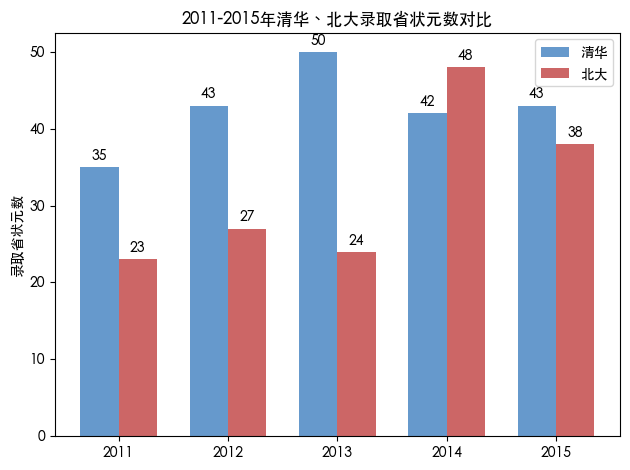

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = [2011, 2012, 2013, 2014, 2015]
# 清华录取省状元数
qinghua = [35, 43, 50, 42, 43]
# 北大录取省状元数
beida = [23, 27, 24, 48, 38]

# 设置条形宽度
bar_width = 0.35
# 生成 x 轴位置，用于放置两组条形
x = np.arange(len(years))  

# 创建图形和坐标轴
fig, ax = plt.subplots()

# 绘制清华的条形
rects1 = ax.bar(x - bar_width/2, qinghua, bar_width, label='清华', color='#6699CC')
# 绘制北大的条形
rects2 = ax.bar(x + bar_width/2, beida, bar_width, label='北大', color='#CC6666')

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(years)
# 设置 y 轴标签
ax.set_ylabel('录取省状元数')
# 设置标题
ax.set_title('2011-2015年清华、北大录取省状元数对比')
# 添加图例
ax.legend()

# 在条形上标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 点垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# 调整布局，避免标签重叠
fig.tight_layout()
# 显示图表
plt.show()

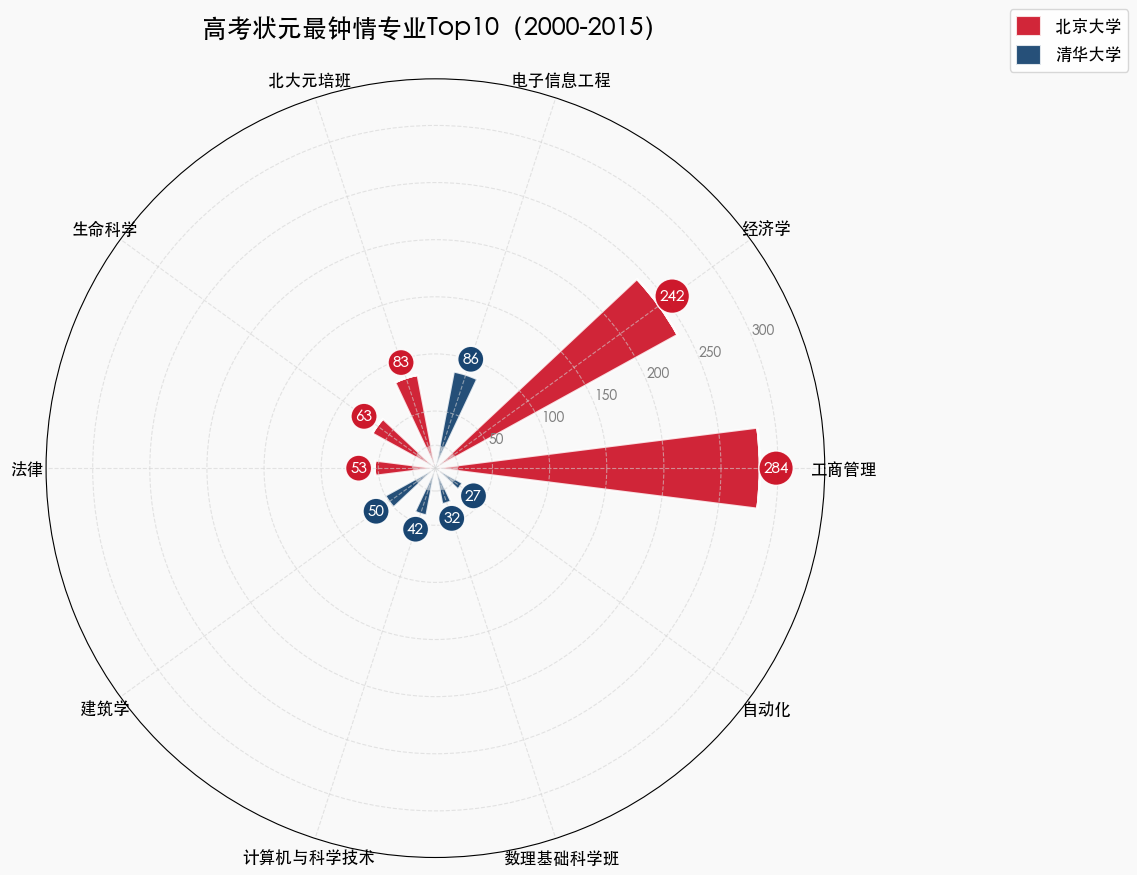

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap

# 专业名称
majors = [
    "工商管理", "经济学", "电子信息工程", "北大元培班", 
    "生命科学", "法律", "建筑学", "计算机与科学技术", 
    "数理基础科学班", "自动化"
]
# 北大、清华对应数据（按专业顺序）
data_pku = [284, 242, 0, 83, 63, 53, 0, 0, 0, 0]
data_tsinghua = [0, 0, 86, 0, 0, 0, 50, 42, 32, 27]

# 极坐标角度，每个专业对应一个角度
angles = np.linspace(0, 2 * np.pi, len(majors), endpoint=False).tolist()
angles += angles[:1]  # 闭合图形

# 创建自定义配色方案
pku_color = '#C90016'  # 北大红
th_color = '#003162'   # 清华蓝
bg_color = '#F9F9F9'   # 背景色

# 创建画布和极坐标子图
fig = plt.figure(figsize=(12, 12), facecolor=bg_color)
ax = plt.subplot(111, polar=True, facecolor=bg_color)

# 绘制北大数据的柱状图
bars_pku = ax.bar(
    angles[:-1], data_pku, width=0.25, 
    color=pku_color, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    label='北京大学'
)

# 绘制清华数据的柱状图
bars_tsinghua = ax.bar(
    angles[:-1], data_tsinghua, width=0.25, 
    color=th_color, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    bottom=data_pku, label='清华大学'
)

# 设置网格线样式
ax.grid(True, color='lightgray', linestyle='--', alpha=0.6)

# 设置极坐标标签（专业名称）
ax.set_thetagrids(np.degrees(angles[:-1]), majors)
plt.setp(ax.get_xticklabels(), fontsize=12, weight='medium')

# 设置径向刻度（隐藏默认刻度，自定义显示）
max_value = max([p + t for p, t in zip(data_pku, data_tsinghua)])
ax.set_ylim(0, max_value * 1.2)
ax.set_rticks([50, 100, 150, 200, 250, 300])
plt.setp(ax.get_yticklabels(), fontsize=10, color='gray')

# 设置标题
plt.title("高考状元最钟情专业Top10（2000-2015）", 
          fontsize=18, fontweight='bold', pad=30)

# 为每个柱子添加数据标注
for i, (angle, pku_val, th_val) in enumerate(zip(angles[:-1], data_pku, data_tsinghua)):
    total_height = pku_val + th_val
    
    # 北大标注
    if pku_val > 0:
        label_r = pku_val + max_value * 0.05
        ax.annotate(
            f"{pku_val}",
            xy=(angle, pku_val),
            xytext=(angle, label_r),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=pku_color, ec='white', alpha=0.9)
        )
    
    # 清华标注
    if th_val > 0:
        label_r = total_height + max_value * 0.05
        ax.annotate(
            f"{th_val}",
            xy=(angle, total_height),
            xytext=(angle, label_r),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=th_color, ec='white', alpha=0.9)
        )

# 自定义图例
legend = ax.legend(
    loc='upper right', 
    bbox_to_anchor=(1.4, 1.1),
    frameon=True,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=12,
    markerscale=1.2,
    handlelength=1.5,
    handleheight=1.5
)
frame = legend.get_frame()
frame.set_facecolor('white')

# 添加中心圆
center_circle = Circle((0, 0), 20, transform=ax.transData._b, 
                       facecolor=bg_color, edgecolor='lightgray', linestyle='--', alpha=0.5)
ax.add_artist(center_circle)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# 显示图表
plt.show()